# Frame Counts for Cryosphere
---

Count  the number of frames for the cryosphere by region.

In [1]:
import geopandas as gpd
import pandas as pd
import fiona
from matplotlib import pyplot as plt
import shapely
from shapely.geometry import Polygon, MultiPolygon
import numpy as np
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'
from datetime import datetime
import pytz
from subprocess import call
import os
import glob
import warnings
from pyproj import CRS
from shapely.geometry import Polygon, mapping, shape, box, Point

## Read Geopackages

In [2]:
cycle =7

In [17]:
bwNames = ['Asc80All', 'Desc80All', 'Asc40All', 'Desc40All', 'Desc20All','Asc20All', 'Asc5All', 'Desc5All']
frames = {}
cycle = 7
for bw in bwNames:
    frames[bw] = gpd.read_file(f'global/cycle{cycle:03d}/{bw}.{cycle:03d}.Framed.gpkg')
print(f'global/cycle{cycle:03d}/{bw}.{cycle:03d}.Framed.gpkg')

global/cycle007/Desc5All.007.Framed.gpkg


## Antarctica

In [67]:
fullFrames, partialFrames = {}, {}
for bw in ['Asc80All', 'Desc80All', 'Asc40All', 'Desc40All']:
    frame = frames[bw][frames[bw].geometry.bounds['maxy'] < -58]
    fullFrames[bw] = frame['produceROFF'].sum()
    partialFrames[bw] = frame.loc[frame['produceROFF'], 'coverage'].sum()
df1 = pd.DataFrame(fullFrames.items(), columns=['Mode', 'FullFrameCount'])  
df2 = pd.DataFrame(partialFrames.items(), columns=['Mode', 'FractionalFrameCount'])  
combined = pd.concat([df1, df2['FractionalFrameCount']], axis=1)  

In [77]:
print(combined[combined['Mode'].isin(['Asc80All', 'Desc80All'])].sum())
print(combined[combined['Mode'].isin(['Asc40All', 'Desc40All'])].sum())

Mode                    Asc80AllDesc80All
FullFrameCount                       1657
FractionalFrameCount          1196.482839
dtype: object
Mode                    Asc40AllDesc40All
FullFrameCount                        813
FractionalFrameCount           479.402383
dtype: object


In [69]:
combined

,Mode,FullFrameCount,FractionalFrameCount
0,Asc80All,830,596.518481
1,Desc80All,827,599.964358
2,Asc40All,398,237.506617
3,Desc40All,415,241.895766


## Greenland

In [79]:
fullFrames, partialFrames = {}, {}
for bw in ['Asc80All', 'Desc80All']:
    frame = frames[bw][frames[bw].geometry.bounds['miny'] > 58]
    fullFrames[bw] = frame['produceROFF'].sum()
    partialFrames[bw] = frame.loc[frame['produceROFF'], 'coverage'].sum()
df1 = pd.DataFrame(fullFrames.items(), columns=['Mode', 'FullFrameCount'])  
df2 = pd.DataFrame(partialFrames.items(), columns=['Mode', 'FractionalFrameCount'])  
combined = pd.concat([df1, df2['FractionalFrameCount']], axis=1)  
print(combined[combined['Mode'].isin(['Asc80All', 'Desc80All'])].sum())
combined

Mode                    Asc80AllDesc80All
FullFrameCount                        356
FractionalFrameCount           267.230832
dtype: object


,Mode,FullFrameCount,FractionalFrameCount
0,Asc80All,180,135.675302
1,Desc80All,176,131.555530


In [ ]:
## Glacie

0.6695495145218522
52
0.6974225630286891
19
0.7878943312541046
25
0.7598654983185702
48
Mode                    Asc40AllDesc40All
FullFrameCount                        587
FractionalFrameCount           399.826589
dtype: object
Mode                    Asc20AllDesc20All
FullFrameCount                        634
FractionalFrameCount           489.518713
dtype: object


,Mode,FullFrameCount,FractionalFrameCount
0,Asc40All,343,229.655483
1,Desc40All,244,170.171105
2,Asc20All,277,218.246730
3,Desc20All,357,271.271983


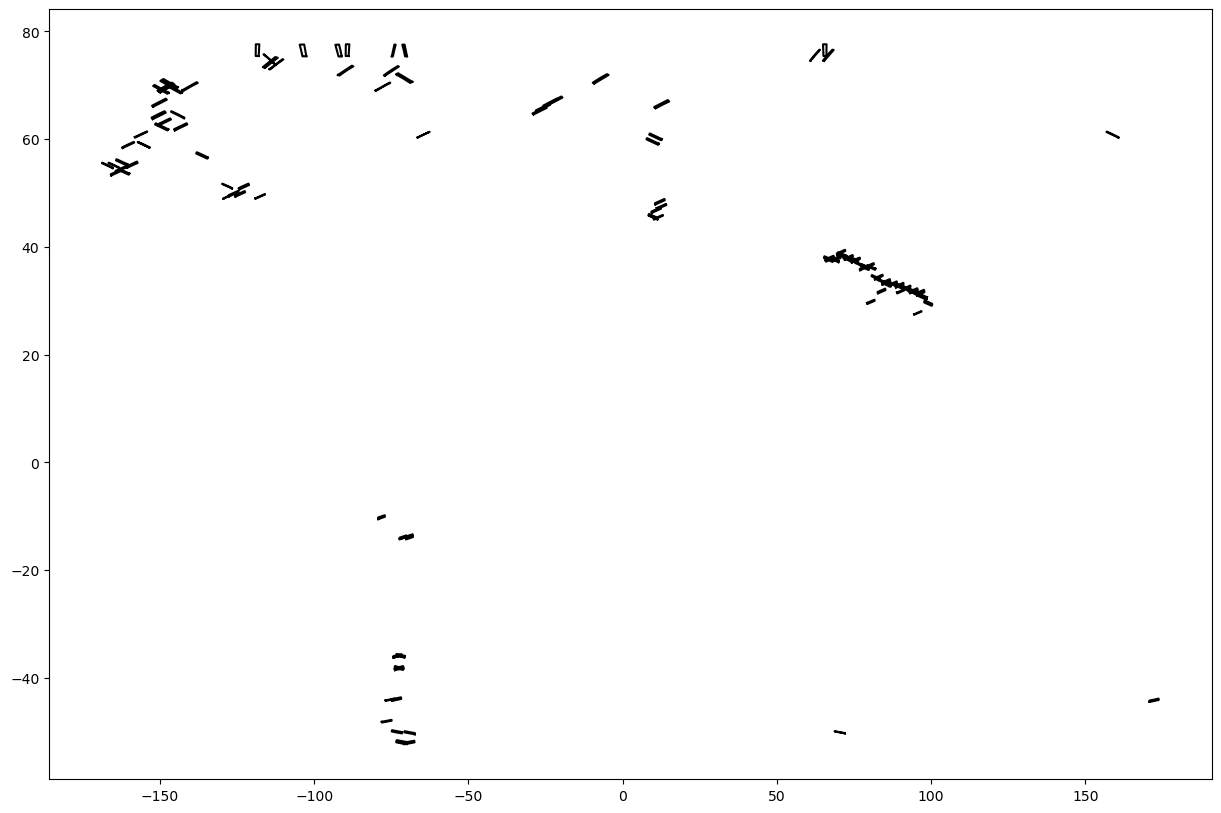

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
fullFrames, partialFrames = {}, {}
for bw in ['Asc40All', 'Desc40All', 'Asc20All', 'Desc20All']:
    frame = frames[bw][frames[bw].geometry.bounds['miny'] > -60]
    fullFrames[bw] = frame['produceROFF'].sum()
    partialFrames[bw] = frame.loc[frame['produceROFF'], 'coverage'].sum()
    pf = frame[frame['produceROFF']]
    print(pf['coverage'].mean())
    count = 0
    for row in pf.iterrows():
        label = None
        if row[1]['coverage'] < 0.15:
            ax.plot(*row[1]['geometry'].exterior.xy, color='k', label=label)
            count += 1
        else:  
            continue
            ax.plot(*row[1]['geometry'].exterior.xy, color='r')
    print(count)

df1 = pd.DataFrame(fullFrames.items(), columns=['Mode', 'FullFrameCount'])  
df2 = pd.DataFrame(partialFrames.items(), columns=['Mode', 'FractionalFrameCount'])  
combined = pd.concat([df1, df2['FractionalFrameCount']], axis=1)  
print(combined[combined['Mode'].isin(['Asc40All', 'Desc40All'])].sum())
print(combined[combined['Mode'].isin(['Asc20All', 'Desc20All'])].sum())
combined

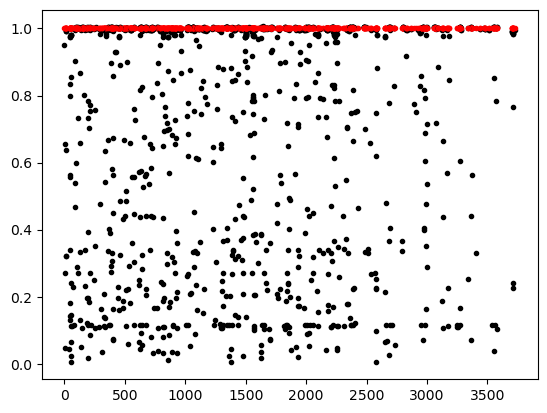

In [43]:
for bw in ['Asc40All', 'Desc40All', 'Asc20All', 'Desc20All']:
    frame = frames[bw][frames[bw].geometry.bounds['miny'] > -60]
    fullFrames[bw] = frame['produceROFF'].sum()
    partialFrames[bw] = frame.loc[frame['produceROFF'], 'coverage'].sum()
    pf = frame[frame['produceROFF']]
    plt.plot(pf['coverage'], 'k.')
    plt.plot(pf['produceROFF'], 'r.')